In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
data_path = '../../data/1minute_data_austin/1minute_data_austin.csv'
df = pd.read_csv(data_path, usecols = ['localminute', 'car1', 'grid', 'dataid', 'solar'])
df['time'] = pd.to_datetime(df['localminute'], utc = True)
df = df.drop(columns = ['localminute'])

In [21]:
df

,dataid,car1,grid,solar,time
0,661,0.0,1.806,-0.002,2018-01-01 07:21:00+00:00
1,661,0.0,1.817,-0.002,2018-01-01 07:00:00+00:00
2,661,0.0,1.804,-0.002,2018-01-01 07:01:00+00:00
3,661,0.0,1.761,-0.002,2018-01-01 07:02:00+00:00
4,661,0.0,1.672,-0.002,2018-01-01 07:03:00+00:00
...,...,...,...,...,...
13100534,7951,NaN,0.550,NaN,2018-02-07 21:26:00+00:00
13100535,7951,NaN,0.660,NaN,2018-02-07 21:27:00+00:00
13100536,7951,NaN,0.456,NaN,2018-02-07 21:28:00+00:00
13100537,7951,NaN,0.339,NaN,2018-02-07 21:29:00+00:00


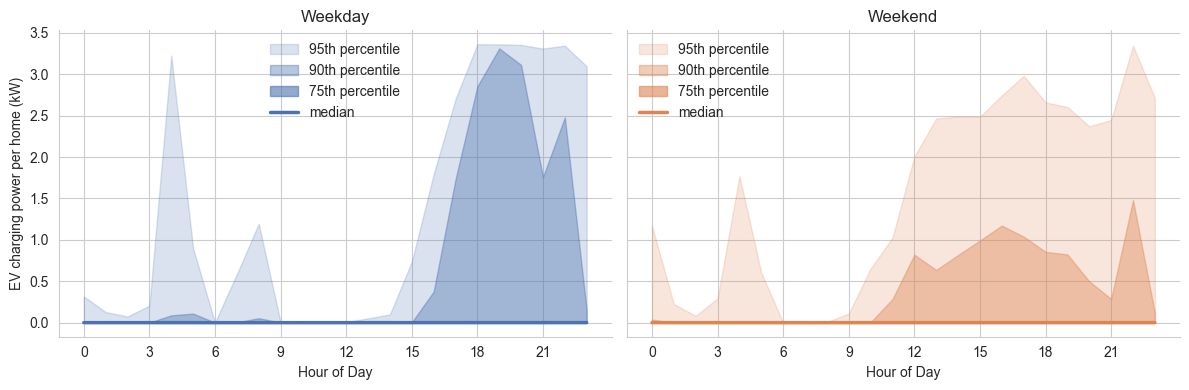

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# convert UTC → Austin local time
tmp = df.copy()
tmp["time"] = pd.to_datetime(tmp["time"], utc=True).dt.tz_convert("America/Chicago")

# local features
tmp["hour"] = tmp["time"].dt.hour
tmp["date"] = tmp["time"].dt.date
tmp["is_weekend"] = tmp["time"].dt.dayofweek >= 5

# collapse to (home, day, hour)
daily = (
    tmp.groupby(["dataid", "date", "hour", "is_weekend"])["car1"]
    .mean()
    .reset_index()
)

# quantiles
qs = [0.5, 0.75, 0.9, 0.95]
dist = (
    daily.groupby(["is_weekend", "hour"])["car1"]
    .quantile(qs)
    .unstack()
    .rename(columns={0.5: "median", 0.75: "q75", 0.9: "q90", 0.95: "q95"})
    .reset_index()
)

weekday = dist[dist["is_weekend"] == False].set_index("hour")
weekend = dist[dist["is_weekend"] == True].set_index("hour")

# ---- plotting ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

palette = sns.color_palette("deep")

for ax, prof, title, color in zip(
    axes,
    [weekday, weekend],
    ["Weekday", "Weekend"],
    palette[:2]
):
    # widest band first (99)
    ax.fill_between(prof.index, 0, prof["q95"], color=color, alpha=0.2, label="95th percentile")
    
    # middle band (90)
    ax.fill_between(prof.index, 0, prof["q90"], color=color, alpha=0.4, label="90th percentile")
    
    # tighter band (75)
    ax.fill_between(prof.index, 0, prof["q75"], color=color, alpha=0.6, label="75th percentile")
    
    # median line on top
    ax.plot(prof.index, prof["median"], color=color, linewidth=2.5, label="median")

    ax.set_title(title)
    ax.set_xlabel("Hour of Day")
    ax.set_xticks(range(0, 24, 3))

axes[0].set_ylabel("EV charging power per home (kW)")

for ax in axes:
    ax.legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
daily.groupby(["is_weekend", "hour"])["car1"].count()

is_weekend  hour
False       0       2075
            1       2074
            2       2073
            3       2076
            4       2075
            5       2074
            6       2074
            7       2075
            8       2074
            9       2075
            10      2075
            11      2071
            12      2071
            13      2071
            14      2073
            15      2072
            16      2072
            17      2071
            18      2071
            19      2074
            20      2073
            21      2073
            22      2073
            23      2074
True        0        824
            1        824
            2        814
            3        822
            4        824
            5        824
            6        823
            7        824
            8        823
            9        823
            10       824
            11       823
            12       823
            13       822
            14       823
        

In [42]:
daily["dataid"].value_counts()

dataid
3039    8759
3538    8759
4031    8759
6139    8759
7951    8759
8386    8759
8565    8759
9278    8759
9922    8759
661     8758
7800    8755
9160    8751
2361    8746
7536    8746
8156    8746
2818    8745
4767    8740
3456    8733
9019    8732
7901    8723
7719    8720
5746    8684
1642    8662
4373    8633
2335    8617
Name: count, dtype: int64

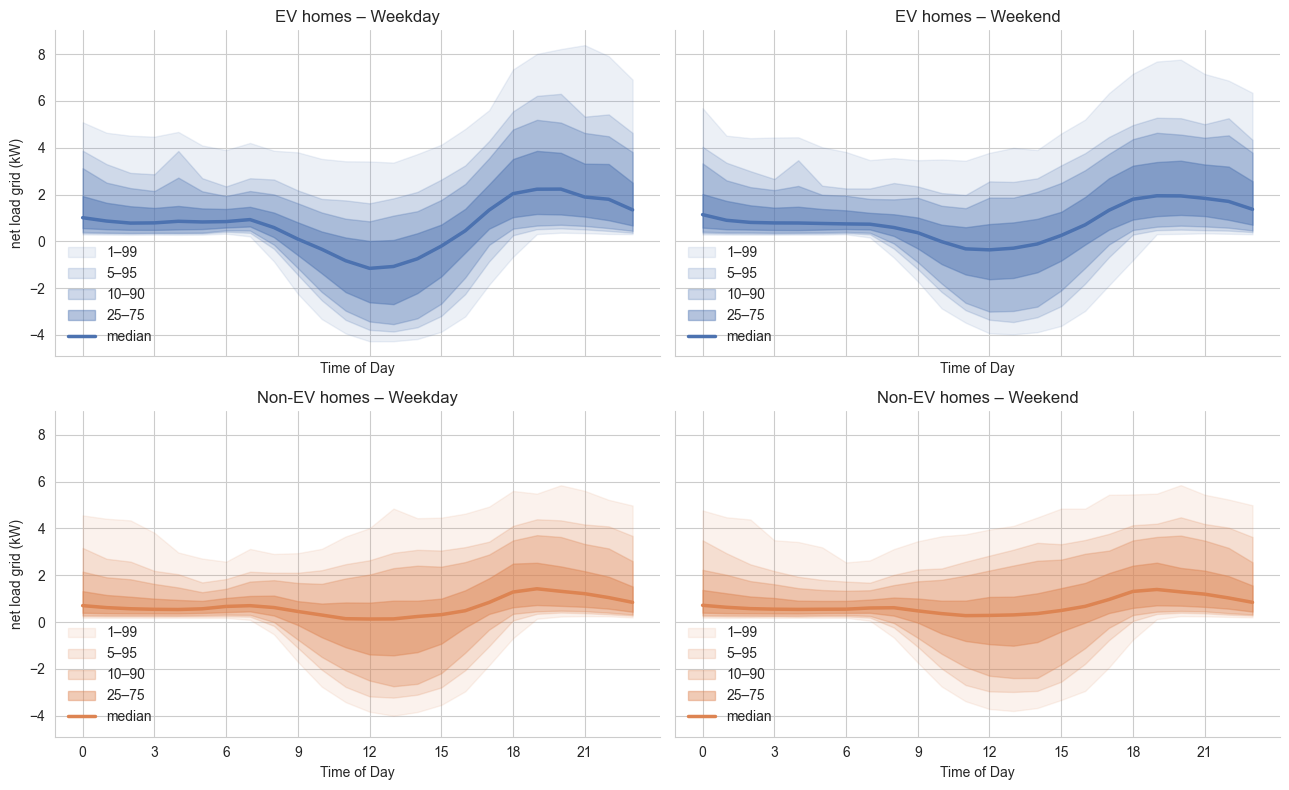

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- classify homes by EV ownership using car1 ---
ev_flag = df.groupby("dataid")["car1"].max().gt(0)
ev_ids = ev_flag[ev_flag].index
non_ev_ids = ev_flag[~ev_flag].index

# --- convert UTC to Austin local time ---
tmp = df.copy()
tmp["time"] = pd.to_datetime(tmp["time"], utc=True).dt.tz_convert("America/Chicago")
tmp["hour"] = tmp["time"].dt.hour
tmp["date"] = tmp["time"].dt.date
tmp["is_weekend"] = tmp["time"].dt.dayofweek >= 5

# --- collapse GRID to one value per (home, day, hour) ---
daily = (
    tmp.groupby(["dataid", "date", "hour", "is_weekend"])["grid"]
    .mean()
    .reset_index()
)

# --- symmetric quantiles for full percentile bands ---
qs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

def compute_dist(df_subset):
    return (
        df_subset.groupby(["is_weekend", "hour"])["grid"]
        .quantile(qs)
        .unstack()
        .rename(columns=lambda q: f"q{int(round(q * 100)):02d}")
        .reset_index()
    )

dist_ev = compute_dist(daily[daily["dataid"].isin(ev_ids)])
dist_non = compute_dist(daily[daily["dataid"].isin(non_ev_ids)])

def split(dist):
    return (
        dist[dist["is_weekend"] == False].set_index("hour"),
        dist[dist["is_weekend"] == True].set_index("hour"),
    )

ev_weekday, ev_weekend = split(dist_ev)
non_weekday, non_weekend = split(dist_non)

# --- plotting ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

panels = [
    ("EV homes – Weekday", ev_weekday),
    ("EV homes – Weekend", ev_weekend),
    ("Non-EV homes – Weekday", non_weekday),
    ("Non-EV homes – Weekend", non_weekend),
]

palette = sns.color_palette("deep")
colors = [palette[0], palette[0], palette[1], palette[1]]

for ax, (title, prof), color in zip(axes.flatten(), panels, colors):
    ax.fill_between(prof.index, prof["q01"], prof["q99"], color=color, alpha=0.10, label="1–99")
    ax.fill_between(prof.index, prof["q05"], prof["q95"], color=color, alpha=0.18, label="5–95")
    ax.fill_between(prof.index, prof["q10"], prof["q90"], color=color, alpha=0.28, label="10–90")
    ax.fill_between(prof.index, prof["q25"], prof["q75"], color=color, alpha=0.42, label="25–75")
    ax.plot(prof.index, prof["q50"], color=color, linewidth=2.5, label="median")

    ax.set_title(title)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("Time of Day")
    ax.legend(frameon=False)

axes[0, 0].set_ylabel("net load grid (kW)")
axes[1, 0].set_ylabel("net load grid (kW)")

sns.despine()
plt.tight_layout()
plt.show()

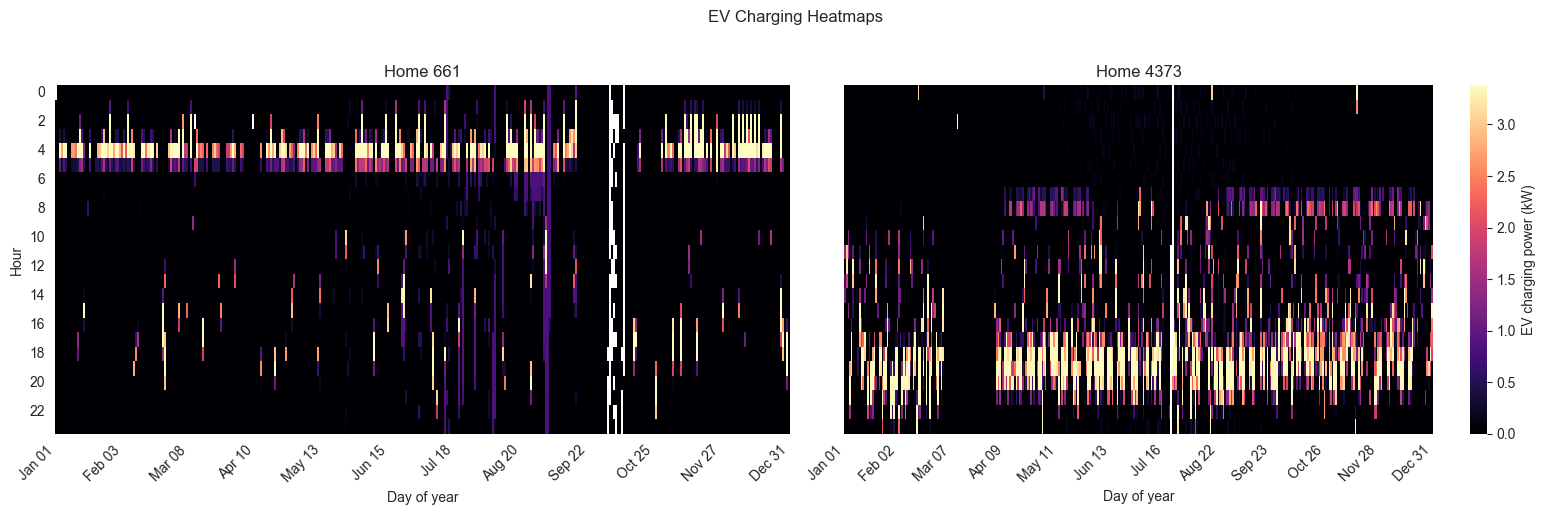

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# --- convert UTC to Austin local time ---
tmp = df.copy()
tmp["time"] = pd.to_datetime(tmp["time"], utc=True).dt.tz_convert("America/Chicago")

home_ids = [661, 4373]

def make_heat(home_id):
    h = tmp[tmp["dataid"] == home_id].copy()
    h["date"] = h["time"].dt.date
    h["hour"] = h["time"].dt.hour

    heat = (
        h.groupby(["hour", "date"])["car1"]
        .mean()
        .unstack("date")
        .reindex(range(24))
    )
    return heat

heat1 = make_heat(home_ids[0])
heat2 = make_heat(home_ids[1])

# --- shared color scale (robust to outliers) ---
vmax = np.nanpercentile(
    np.concatenate([heat1.values.flatten(), heat2.values.flatten()]),
    99
)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, heat, hid in zip(axes, [heat1, heat2], home_ids):
    sns.heatmap(
        heat,
        ax=ax,
        cmap="magma",
        vmin=0,
        vmax=vmax,
        cbar=ax is axes[1],
        cbar_kws={"label": "EV charging power (kW)"} if ax is axes[1] else None,
    )

    ax.set_title(f"Home {hid}")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Hour" if ax is axes[0] else "")

    # cleaner x ticks
    date_cols = pd.to_datetime(heat.columns)
    xtick_idx = np.linspace(0, len(date_cols) - 1, min(12, len(date_cols))).astype(int)

    ax.set_xticks(xtick_idx + 0.5)
    ax.set_xticklabels(
        [date_cols[i].strftime("%b %d") for i in xtick_idx],
        rotation=45,
        ha="right",
    )

axes[0].set_yticks(np.arange(0.5, 24.5, 2))
axes[0].set_yticklabels(range(0, 24, 2), rotation=0)

plt.suptitle("EV Charging Heatmaps", y=1.02)
plt.tight_layout()
plt.show()